# Tile test: accuracy and classification time

Line plots for **concentric circles** and **plant tissue** from `test-results/tile-tests/`. The example cell overlays **IBM Marrakesh** (solid lines, round markers) and **Fake Marrakesh** (dashed lines, square markers) on the same axes.

**Mean-accuracy** line plots use vertical error bars from the CSV column `mean_accuracy_sem` (standard error of the mean over repeated pipeline iterations). Re-run the experiment CSV export if that column is missing.

Thanks CursorAI

In [30]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, ScalarFormatter

# Load CSVs from repo root whether the kernel cwd is the project root or exploration_notebooks/
def _figures_output_dir() -> Path:
    """Use the thesis repo's ``figures/`` (same directory that holds ``exploration_notebooks/``)."""
    cwd = Path.cwd().resolve()
    if cwd.name == "exploration_notebooks":
        out = cwd.parent / "figures"
    else:
        out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out.resolve()


cwd = Path.cwd().resolve()
plot_dir = _figures_output_dir()
MEAN_ACCURACY_YLABEL = "Mean accuracy"

def _load_tile_test_csv(filename: str) -> pd.DataFrame:
    cwd = Path.cwd().resolve()
    for root in (cwd, cwd.parent):
        path = root / filename
        if path.is_file():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find {filename} under {cwd} or {cwd.parent}. "
        "Open the notebook from the repo or set the kernel cwd to exploration_notebooks/."
    )


def _tile_edge_and_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[int], list[float]]:
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].tolist(), tmp[ycol].astype(float).tolist()


def _tile_edge_mean_accuracy_series(
    df: pd.DataFrame,
) -> tuple[list[int], list[float], list[float] | None]:
    """Tile edge vs ``mean_accuracy``; optional ``mean_accuracy_sem`` (SEM across repeated iterations)."""
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    x = tmp["_edge"].tolist()
    y = tmp["mean_accuracy"].astype(float).tolist()
    if "mean_accuracy_sem" in tmp.columns:
        yerr = tmp["mean_accuracy_sem"].astype(float).tolist()
    else:
        yerr = None
    return x, y, yerr


def _shot_scale_mean_accuracy_series(
    df: pd.DataFrame,
) -> tuple[list[float], list[float], list[float] | None]:
    tmp = df.copy().sort_values("shot_scale_2_pow_k")
    x = tmp["shot_scale_2_pow_k"].astype(float).tolist()
    y = tmp["mean_accuracy"].astype(float).tolist()
    if "mean_accuracy_sem" in tmp.columns:
        yerr = tmp["mean_accuracy_sem"].astype(float).tolist()
    else:
        yerr = None
    return x, y, yerr


def _plot_mean_accuracy_line(
    ax: plt.Axes,
    x,
    y: list[float],
    yerr: list[float] | None,
    *,
    capsize: float = 3,
    **kwargs,
) -> None:
    """Line or errorbar plot for mean accuracy; uses error bars when ``yerr`` is provided."""
    if yerr is not None:
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            capsize=capsize,
            elinewidth=1,
            **kwargs,
        )
    else:
        ax.plot(x, y, **kwargs)


def _apply_tile_xaxis_log2(ax: plt.Axes, edges: set[int]) -> None:
    """Use log₂ x so equal ratios of tile edge (2→4→8→…) get equal visual spacing."""
    ticks = sorted(edges)
    if not ticks:
        return
    ax.set_xscale("log", base=2)
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(NullLocator())


def plot_mean_accuracy(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y, yerr = _tile_edge_mean_accuracy_series(df)
        _plot_mean_accuracy_line(
            ax, x, y, yerr, marker="o", linewidth=2, label=lab, color=color
        )

    ax.set_xlabel("Square tile size (log₂ x-axis)")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _tile_edges = set(_tile_edge_and_sorted(circle_df, "mean_accuracy")[0]) | set(
        _tile_edge_and_sorted(plant_df, "mean_accuracy")[0]
    )
    _apply_tile_xaxis_log2(ax, _tile_edges)
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Average Classification Time vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size (log₂ x-axis)")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _tile_edges = set(_tile_edge_and_sorted(circle_df, "avg_classification_s")[0]) | set(
        _tile_edge_and_sorted(plant_df, "avg_classification_s")[0]
    )
    _apply_tile_xaxis_log2(ax, _tile_edges)
    fig.tight_layout()
    return fig, ax


def _unpack_tile_overlay_row(
    row: tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str],
) -> tuple[pd.DataFrame, str, str, str, str]:
    """(df, label, color, linestyle) or add optional ``marker`` (``o`` = hardware, ``s`` = fake).

    If marker is omitted: solid ``-`` → round ``o``; any other linestyle → square ``s``.
    """
    if len(row) == 5:
        df, lab, color, ls, mk = row
        return df, lab, color, ls, mk
    df, lab, color, ls = row
    mk = "o" if ls.strip() == "-" else "s"
    return df, lab, color, ls, mk


def plot_mean_accuracy_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Multiple overlays; each row is (df, label, color, linestyle) or (... , marker)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y, yerr = _tile_edge_mean_accuracy_series(df)
        all_edges.update(x)
        _plot_mean_accuracy_line(
            ax,
            x,
            y,
            yerr,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size (log₂ x-axis)")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _apply_tile_xaxis_log2(ax, all_edges)
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = "Average Classification Time vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Same rows as ``plot_mean_accuracy_multi`` (optional per-series marker)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y = _tile_edge_and_sorted(df, "avg_classification_s")
        all_edges.update(x)
        ax.plot(
            x,
            y,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size (log₂ x-axis)")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _apply_tile_xaxis_log2(ax, all_edges)
    fig.tight_layout()
    return fig, ax


def _shot_scale_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[float], list[float]]:
    """Sort by ``shot_scale_2_pow_k`` (2**k) for line plots vs shot budget."""
    tmp = df.copy()
    tmp = tmp.sort_values("shot_scale_2_pow_k")
    return (
        tmp["shot_scale_2_pow_k"].astype(float).tolist(),
        tmp[ycol].astype(float).tolist(),
    )


def plot_mean_accuracy_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs shot scale",
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y, yerr = _shot_scale_mean_accuracy_series(df)
        _plot_mean_accuracy_line(
            ax, x, y, yerr, marker="o", linewidth=2, label=lab, color=color
        )

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "mean_accuracy")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Average classification time vs shot scale",
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y = _shot_scale_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "avg_classification_s")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax

NameError: name 'MEAN_ACCURACY_YLABEL' is not defined

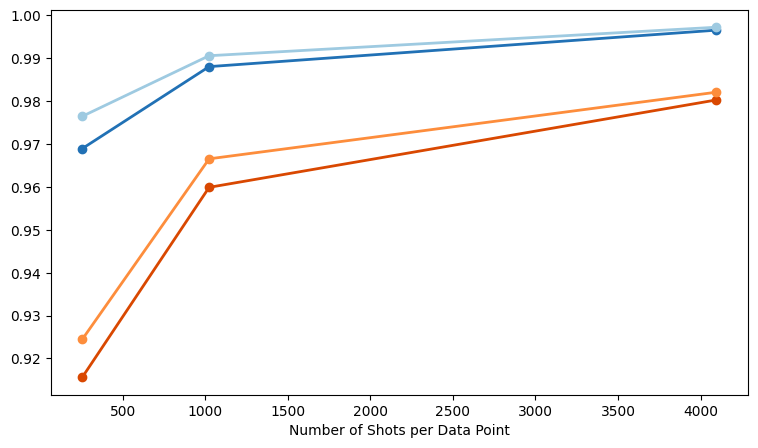

In [ ]:
# 64x64 iso-0.5 shot-scale sweeps: synthetic (circle) + plant on shared axes (-n vs -t CSVs)
circle_iso_n_df = _load_tile_test_csv("../test-results/iso-weight-enc/circle_64x64_method_1_iso-0.5-n_results.csv")
circle_iso_t_df = _load_tile_test_csv("../test-results/iso-weight-enc/circle_64x64_method_1_iso-0.5-t_results.csv")
plant_iso_n_df = _load_tile_test_csv("../test-results/iso-weight-enc/plant_2_64x64_method_1_iso-0.5-n_results.csv")
plant_iso_t_df = _load_tile_test_csv("../test-results/iso-weight-enc/plant_2_64x64_method_1_iso-0.5-t_results.csv")

SHOT_LABEL_A = "Baseline method"
SHOT_LABEL_B = "Isovalue-Weight Encoding"
COMBINED_SHOT_TITLE = (
    "64×64 classification (iso −0.5): "
    f"{SHOT_LABEL_A} vs {SHOT_LABEL_B}"
)

# Synthetic = blue pair; plant = orange pair (darker = baseline -n, lighter = isovalue -t)
_shot_series = (
    (circle_iso_n_df, f"Synthetic: {SHOT_LABEL_A}", "#2171b5"),
    (circle_iso_t_df, f"Synthetic: {SHOT_LABEL_B}", "#9ecae1"),
    (plant_iso_n_df, f"Plant: {SHOT_LABEL_A}", "#d94801"),
    (plant_iso_t_df, f"Plant: {SHOT_LABEL_B}", "#fd8d3c"),
)

_x_all = sorted(
    set()
    .union(*(_shot_scale_sorted(df, "mean_accuracy")[0] for df, _, _ in _shot_series))
    .union(*(_shot_scale_sorted(df, "avg_classification_s")[0] for df, _, _ in _shot_series))
)

fig_acc, ax_acc = plt.subplots(figsize=(9, 5))
for df, lab, color in _shot_series:
    x, y, yerr = _shot_scale_mean_accuracy_series(df)
    _plot_mean_accuracy_line(
        ax_acc, x, y, yerr, marker="o", linewidth=2, label=lab, color=color
    )
ax_acc.set_xlabel("Number of Shots per Data Point")
ax_acc.set_ylabel(MEAN_ACCURACY_YLABEL)
ax_acc.set_title(COMBINED_SHOT_TITLE)
ax_acc.legend()
ax_acc.grid(True, alpha=0.35)
ax_acc.set_xscale("log")
ax_acc.set_xticks(_x_all)
ax_acc.get_xaxis().set_major_formatter(ScalarFormatter())
fig_acc.tight_layout()

combined_shot_acc_path = plot_dir / "combined_64x64_iso-0.5_shot_scale_mean_accuracy.png"
fig_acc.savefig(combined_shot_acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {combined_shot_acc_path.resolve()}")
plt.show()

fig_time, ax_time = plt.subplots(figsize=(9, 5))
for df, lab, color in _shot_series:
    x, y = _shot_scale_sorted(df, "avg_classification_s")
    ax_time.plot(x, y, marker="o", linewidth=2, label=lab, color=color)
ax_time.set_xlabel("Number of Shots per Data Point")
ax_time.set_ylabel("Average classification time (s)")
ax_time.set_title(COMBINED_SHOT_TITLE)
ax_time.legend()
ax_time.grid(True, alpha=0.35)
ax_time.set_xscale("log")
ax_time.set_xticks(_x_all)
ax_time.get_xaxis().set_major_formatter(ScalarFormatter())
fig_time.tight_layout()

combined_shot_time_path = plot_dir / "combined_64x64_iso-0.5_shot_scale_avg_classification_s.png"
fig_time.savefig(combined_shot_time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {combined_shot_time_path.resolve()}")
plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\marrakesh_tile_test_depth_vs_mean_accuracy.png


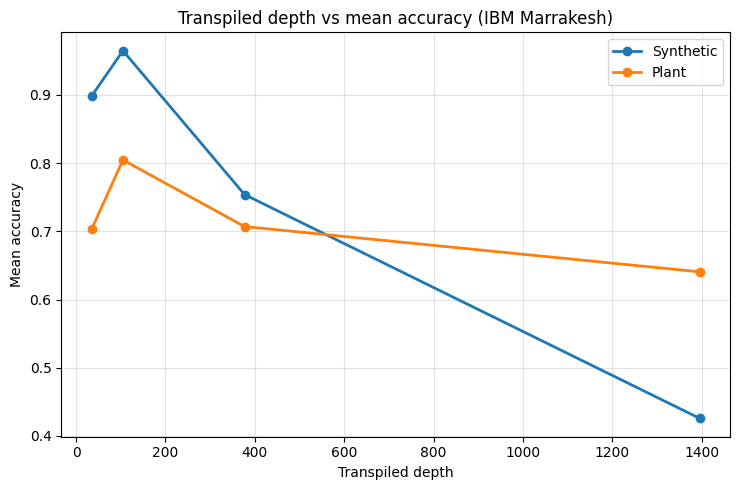

In [ ]:
# Depth vs accuracy (transpiled depth from JobOutputs JSON, mean accuracy from tile-test CSV)
# Assumes 16x16 images => n_tiles = (16 / tile_edge)^2
import json

JOB_INFO_PATH = "../JobOutputs/job_submission_info.json"

job_info = json.loads(Path(JOB_INFO_PATH).read_text(encoding="utf-8"))


def _expected_n_tiles(tile_edge: int, full_edge: int = 16) -> int:
    if full_edge % tile_edge != 0:
        raise ValueError(f"full_edge={full_edge} not divisible by tile_edge={tile_edge}")
    return (full_edge // tile_edge) ** 2


def _depth_for_tile_edge(tile_edge: int) -> int:
    want_n_tiles = _expected_n_tiles(tile_edge)

    # Prefer the aggregated tile-test jobs (these include n_tiles)
    for rec in job_info.values():
        if rec.get("tile_width") == tile_edge and rec.get("tile_height") == tile_edge and rec.get("n_tiles") == want_n_tiles:
            return int(rec["transpiled_depth"])

    # Fallback: any matching tile size
    for rec in job_info.values():
        if rec.get("tile_width") == tile_edge and rec.get("tile_height") == tile_edge:
            return int(rec["transpiled_depth"])

    raise KeyError(f"No job found for tile_edge={tile_edge}")


def _depth_vs_accuracy_points(
    df: pd.DataFrame,
) -> tuple[list[int], list[float], list[float] | None]:
    edges, acc, acc_sem = _tile_edge_mean_accuracy_series(df)
    depths = [_depth_for_tile_edge(e) for e in edges]
    return depths, acc, acc_sem


# Use the already-loaded circle_ibm / plant_ibm if present (from earlier cells); otherwise load them.
try:
    circle_df_for_depth = circle_ibm
    plant_df_for_depth = plant_ibm
except NameError:
    circle_df_for_depth = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv")
    plant_df_for_depth = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv")

x_circle, y_circle, yerr_circle = _depth_vs_accuracy_points(circle_df_for_depth)
x_plant, y_plant, yerr_plant = _depth_vs_accuracy_points(plant_df_for_depth)

# Sort by depth so the lines connect left-to-right
if yerr_circle is None:
    circle_pairs = sorted(zip(x_circle, y_circle))
    x_circle_s, y_circle_s = (list(t) for t in zip(*circle_pairs))
    yerr_circle_s = None
else:
    circle_pairs = sorted(zip(x_circle, y_circle, yerr_circle))
    x_circle_s, y_circle_s, yerr_circle_s = (list(t) for t in zip(*circle_pairs))

if yerr_plant is None:
    plant_pairs = sorted(zip(x_plant, y_plant))
    x_plant_s, y_plant_s = (list(t) for t in zip(*plant_pairs))
    yerr_plant_s = None
else:
    plant_pairs = sorted(zip(x_plant, y_plant, yerr_plant))
    x_plant_s, y_plant_s, yerr_plant_s = (list(t) for t in zip(*plant_pairs))

fig, ax = plt.subplots(figsize=(7.5, 5))
_plot_mean_accuracy_line(
    ax,
    x_circle_s,
    y_circle_s,
    yerr_circle_s,
    label="Synthetic",
    color="#1f77b4",
    marker="o",
    linewidth=2,
)
_plot_mean_accuracy_line(
    ax,
    x_plant_s,
    y_plant_s,
    yerr_plant_s,
    label="Plant",
    color="#ff7f0e",
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Transpiled depth")
ax.set_ylabel(MEAN_ACCURACY_YLABEL)
ax.set_title("Transpiled depth vs mean accuracy (IBM Marrakesh)")
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()

out_path = plot_dir / "marrakesh_tile_test_depth_vs_mean_accuracy.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path.resolve()}")
plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\aer_tile_test_mean_accuracy_bars.png


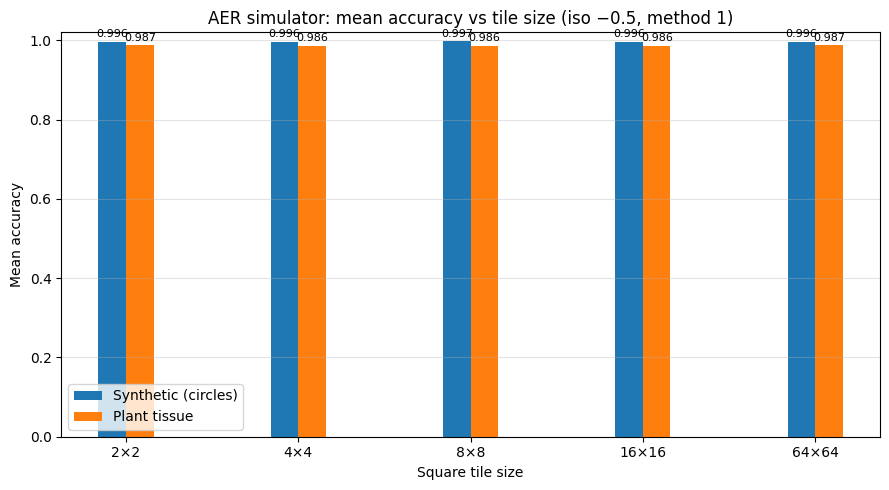

In [ ]:
# AER tile test: grouped bar chart — tile size vs mean accuracy (circle + plant)
# Default CSVs are the matched 64×64 iso-0.5 pair under ``test-results/tile-tests/aer/``.
import numpy as np


def _tile_edges_and_accuracy_bars(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Drop blank trailing rows, parse square edge from ``tile_size`` (e.g. ``8x8``), sort by edge."""
    tmp = df.dropna(subset=["tile_size"]).copy()
    tmp = tmp[tmp["tile_size"].astype(str).str.strip() != ""]
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].to_numpy(), tmp["mean_accuracy"].astype(float).to_numpy()

    """Drop blank trailing rows, parse square edge from ``tile_size`` (e.g. ``8x8``), sort by edge."""
    tmp = df.dropna(subset=["tile_size"]).copy()
    tmp = tmp[tmp["tile_size"].astype(str).str.strip() != ""]
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].to_numpy(), tmp["mean_accuracy"].astype(float).to_numpy()


# Paths relative to ``exploration_notebooks/`` when cwd is the repo root or this folder
AER_CIRCLE_TILE_CSV = "../test-results/tile-tests/aer/circle_2_64x64_method_1_iso-0.5_aer_results.csv"
AER_PLANT_TILE_CSV = "../test-results/tile-tests/aer/plant_2_64x64_method_1_iso-0.5_aer_results.csv"

circle_aer_df = _load_tile_test_csv(AER_CIRCLE_TILE_CSV)
plant_aer_df = _load_tile_test_csv(AER_PLANT_TILE_CSV)

x_circle, y_circle = _tile_edges_and_accuracy_bars(circle_aer_df)
x_plant, y_plant = _tile_edges_and_accuracy_bars(plant_aer_df)

# Align on common tile sizes (in case one CSV omits a row)
common = np.intersect1d(x_circle, x_plant, assume_unique=True)
if len(common) == 0:
    raise ValueError("No overlapping tile sizes between circle and plant AER CSVs.")
idx_c = np.searchsorted(x_circle, common)
idx_p = np.searchsorted(x_plant, common)
y_c = y_circle[idx_c]
y_p = y_plant[idx_p]

width = min(0.35, 0.8 / max(2, len(common)))
_x = np.arange(len(common))

fig, ax = plt.subplots(figsize=(9, 5))
bars_c = ax.bar(_x - width / 2, y_c, width, label="Synthetic (circles)", color="#1f77b4")
bars_p = ax.bar(_x + width / 2, y_p, width, label="Plant tissue", color="#ff7f0e")

ax.set_xticks(_x, [f"{int(e)}×{int(e)}" for e in common])
ax.set_xlabel("Square tile size")
ax.set_ylabel("Mean accuracy")
ax.set_title("AER simulator: mean accuracy vs tile size (iso −0.5, method 1)")
ax.legend()
ax.grid(True, axis="y", alpha=0.35)
ax.set_ylim(0.0, 1.02)

for bars in (bars_c, bars_p):
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

fig.tight_layout()
aer_bar_path = plot_dir / "aer_tile_test_mean_accuracy_bars.png"
fig.savefig(aer_bar_path, dpi=300, bbox_inches="tight")
print(f"Saved: {aer_bar_path.resolve()}")
plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\fake_torino_vs_aer_tile_test_mean_accuracy.png


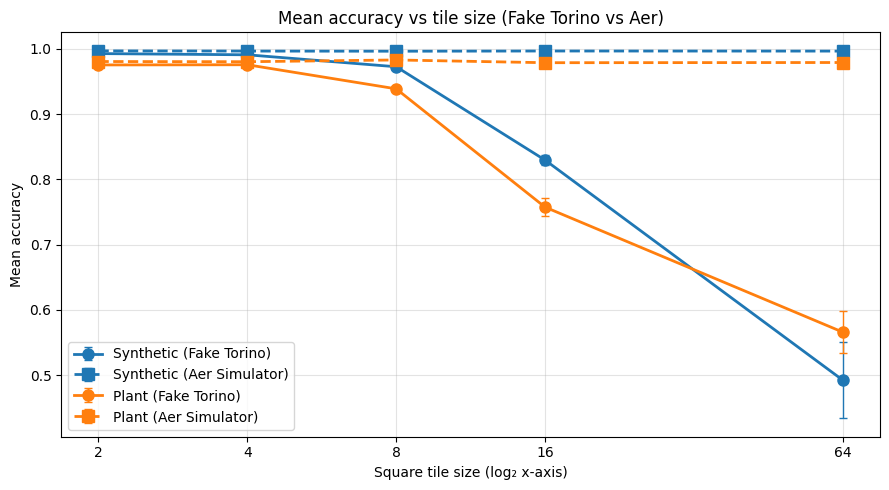

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\fake_torino_vs_aer_tile_test_avg_classification_s.png


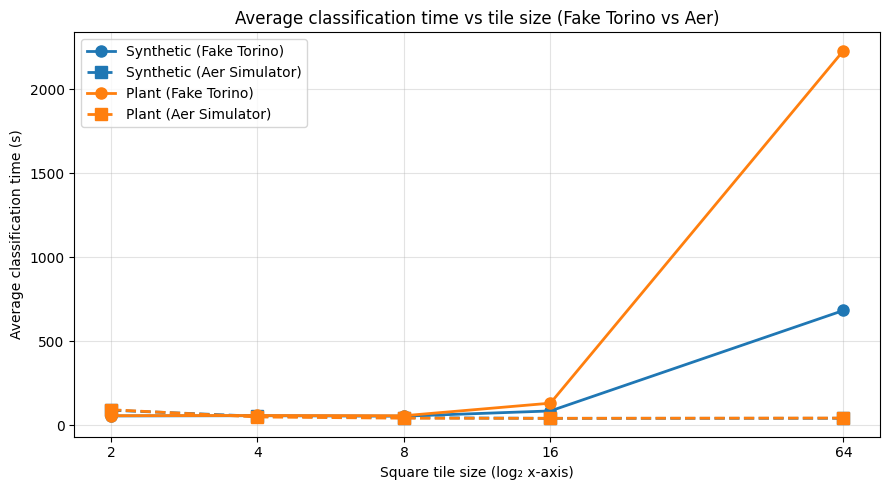

In [ ]:
COLORS = ("#1f77b4", "#ff7f0e")

circle_torino = _load_tile_test_csv("../circle_64x64_method_1_iso_0_torino_sc12_results.csv")
plant_torino = _load_tile_test_csv("../plant_2_64x64_method_1_iso-0.5_torino_sc12_results.csv")
circle_aer = _load_tile_test_csv("../circle_64x64_method_1_iso_0_aer_sc12_results.csv")
plant_aer = _load_tile_test_csv("../plant_2_64x64_method_1_iso-0.5_aer_sc12_results.csv")

_acc_series = [
    (circle_torino, "Synthetic (Fake Torino)", COLORS[0], "-"),
    (circle_aer, "Synthetic (Aer Simulator)", COLORS[0], "--"),
    (plant_torino, "Plant (Fake Torino)", COLORS[1], "-"),
    (plant_aer, "Plant (Aer Simulator)", COLORS[1], "--")
]

fig_acc, _ = plot_mean_accuracy_multi(
    _acc_series,
    title="Mean accuracy vs tile size (Fake Torino vs Aer)",
)
acc_path = plot_dir / "fake_torino_vs_aer_tile_test_mean_accuracy.png"
fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {acc_path.resolve()}")
plt.show()

fig_time, _ = plot_avg_classification_s_multi(
    _acc_series,
    title="Average classification time vs tile size (Fake Torino vs Aer)",
)
time_path = plot_dir / "fake_torino_vs_aer_tile_test_avg_classification_s.png"
fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {time_path.resolve()}")
plt.show()



Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_synthetic_tile_test_mean_accuracy.png


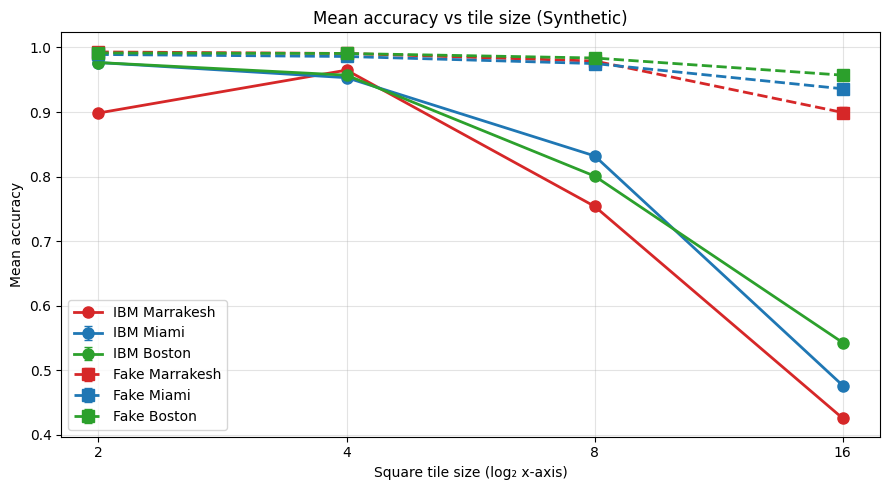

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_synthetic_tile_test_avg_classification_s.png


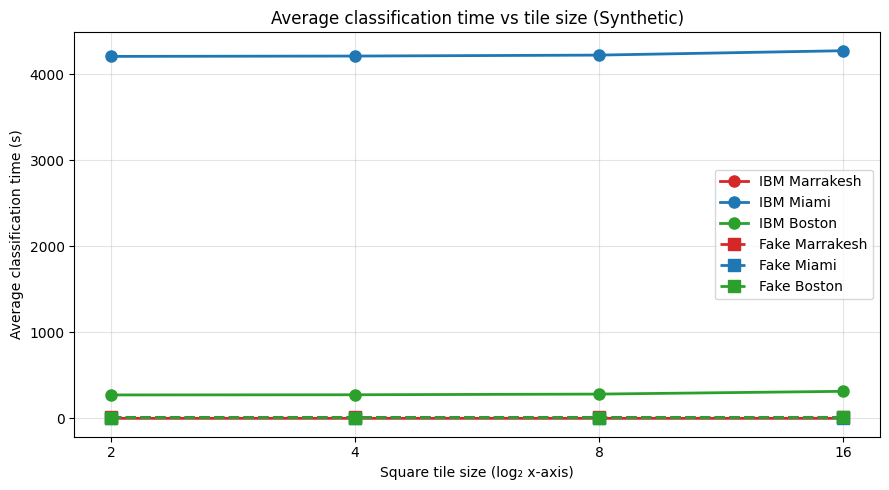

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_plant_tile_test_mean_accuracy.png


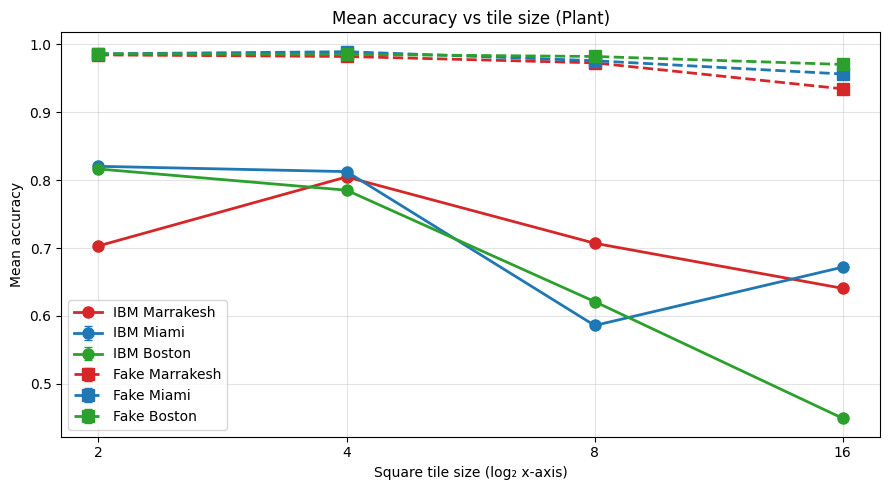

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_plant_tile_test_avg_classification_s.png


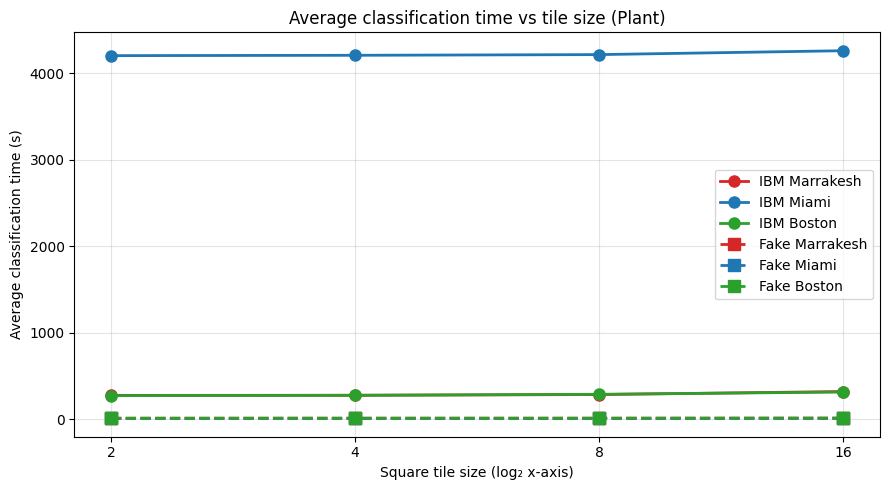

In [ ]:
# ex3 tile test: IBM Marrakesh, Miami, and Boston (solid) vs matching fakes (dashed)
# Synthetic and plant each get their own accuracy + classification-time figure.
EX3_DIR = "../test-results/tile-tests/ex3"
BACKEND_COLORS = ("#d62728", "#1f77b4", "#2ca02c")  # Marrakesh (red), Miami (blue), Boston (green)

_ex3_synthetic_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/circle_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/circle_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/circle_16x16_method_1_iso_0_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/circle_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/circle_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

_ex3_plant_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/plant_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/plant_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/plant_2_16x16_method_1_iso-0.5_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/plant_2_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/plant_2_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

for _label, _series, _stem in (
    ("Synthetic", _ex3_synthetic_series, "ex3_synthetic"),
    ("Plant", _ex3_plant_series, "ex3_plant"),
):
    fig_acc, _ = plot_mean_accuracy_multi(
        _series,
        title=f"Mean accuracy vs tile size ({_label})",
    )
    acc_path = plot_dir / f"{_stem}_tile_test_mean_accuracy.png"
    fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {acc_path.resolve()}")
    plt.show()

    fig_time, _ = plot_avg_classification_s_multi(
        _series,
        title=f"Average classification time vs tile size ({_label})",
    )
    time_path = plot_dir / f"{_stem}_tile_test_avg_classification_s.png"
    fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {time_path.resolve()}")
    plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\iso_weight_enc_shot_count_mean_accuracy.png


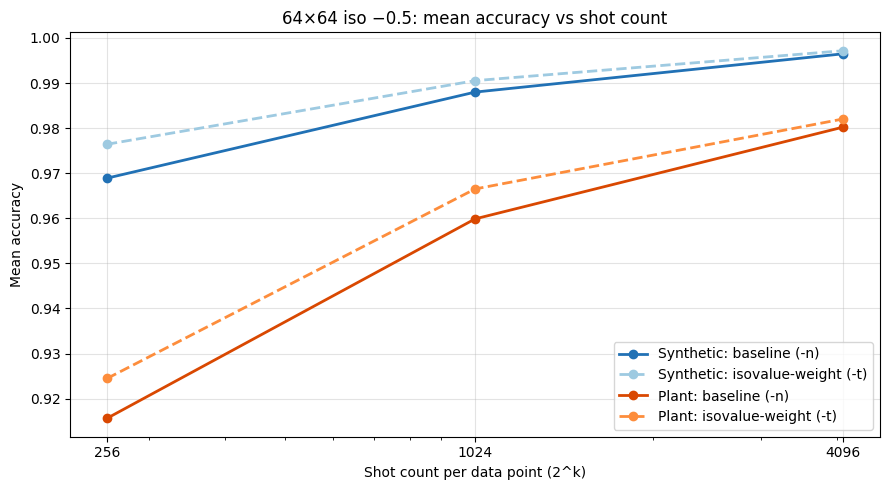

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\iso_weight_enc_shot_count_avg_classification_s.png


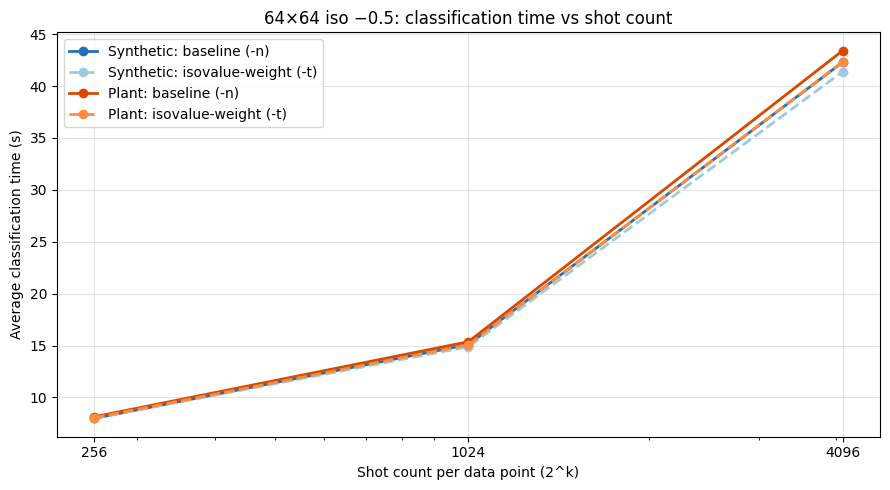

In [ ]:
# 64×64 iso-weight encoding: shot count vs accuracy & classification time
# Circle + plant on each chart; baseline (-n) vs isovalue-weight (-t).
ISO_WEIGHT_DIR = "../test-results/iso-weight-enc"

_iso_shot_series = (
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/circle_64x64_method_1_iso-0.5-n_results.csv"),
        "Synthetic: baseline (-n)",
        "#2171b5",
        "-",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/circle_64x64_method_1_iso-0.5-t_results.csv"),
        "Synthetic: isovalue-weight (-t)",
        "#9ecae1",
        "--",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/plant_2_64x64_method_1_iso-0.5-n_results.csv"),
        "Plant: baseline (-n)",
        "#d94801",
        "-",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/plant_2_64x64_method_1_iso-0.5-t_results.csv"),
        "Plant: isovalue-weight (-t)",
        "#fd8d3c",
        "--",
    ),
)

_shot_x_all = sorted(
    set()
    .union(*(_shot_scale_sorted(df, "mean_accuracy")[0] for df, _, _, _ in _iso_shot_series))
    .union(*(_shot_scale_sorted(df, "avg_classification_s")[0] for df, _, _, _ in _iso_shot_series))
)

fig_iso_acc, ax_iso_acc = plt.subplots(figsize=(9, 5))
for df, lab, color, ls in _iso_shot_series:
    x, y, yerr = _shot_scale_mean_accuracy_series(df)
    _plot_mean_accuracy_line(
        ax_iso_acc, x, y, yerr, marker="o", linewidth=2, label=lab, color=color, linestyle=ls
    )
ax_iso_acc.set_xlabel("Shot count per data point (2^k)")
ax_iso_acc.set_ylabel(MEAN_ACCURACY_YLABEL)
ax_iso_acc.set_title("64×64 iso 0: mean accuracy vs shot count")
ax_iso_acc.legend()
ax_iso_acc.grid(True, alpha=0.35)
ax_iso_acc.set_xscale("log")
ax_iso_acc.set_xticks(_shot_x_all)
ax_iso_acc.get_xaxis().set_major_formatter(ScalarFormatter())
fig_iso_acc.tight_layout()
_iso_acc_path = plot_dir / "iso_weight_enc_shot_count_mean_accuracy.png"
fig_iso_acc.savefig(_iso_acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {_iso_acc_path.resolve()}")
plt.show()

fig_iso_time, ax_iso_time = plt.subplots(figsize=(9, 5))
for df, lab, color, ls in _iso_shot_series:
    x, y = _shot_scale_sorted(df, "avg_classification_s")
    ax_iso_time.plot(x, y, marker="o", linewidth=2, label=lab, color=color, linestyle=ls)
ax_iso_time.set_xlabel("Shot count per data point (2^k)")
ax_iso_time.set_ylabel("Average classification time (s)")
ax_iso_time.set_title("64×64 iso 0: classification time vs shot count")
ax_iso_time.legend()
ax_iso_time.grid(True, alpha=0.35)
ax_iso_time.set_xscale("log")
ax_iso_time.set_xticks(_shot_x_all)
ax_iso_time.get_xaxis().set_major_formatter(ScalarFormatter())
fig_iso_time.tight_layout()
_iso_time_path = plot_dir / "iso_weight_enc_shot_count_avg_classification_s.png"
fig_iso_time.savefig(_iso_time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {_iso_time_path.resolve()}")
plt.show()
